# Use AutoAI with Watson Studio project `ibm-watsonx-ai`

This notebook contains the steps and code to demonstrate support of AutoAI experiments in watsonx.ai service inside Watson Studio's projects. It introduces commands for data retrieval, training experiments and scoring.

Some familiarity with Python is helpful. This notebook uses Python 3.12.


## Learning goals

The learning goals of this notebook are:

-  Work with watsonx.ai experiments to train AutoAI model using Watson Studio project.
-  Online, Batch deployment and score the trained model trained.


## Contents

This notebook contains the following parts:

1. [Set up the environment](#1.-Set-up-the-environment)
2. [Optimizer definition](#2.-Optimizer-definition)
3. [Experiment run](#3.-Experiment-run)
4. [Deploy and Score](#4.-Deploy-and-Score)
5. [Cleanup](#5.-Cleanup)
6. [Summary and next steps](#6.-Summary-and-next-steps)

<a id="1.-Set-up-the-environment"></a>
## 1. Set up the environment

Before you use the sample code in this notebook, you must perform the following setup tasks:

-  Contact with your IBM Cloud Pak® for Data administrator and ask them for your account credentials

### Install dependencies
**Note:** `ibm-watsonx-ai` documentation can be found <a href="https://ibm.github.io/watsonx-ai-python-sdk/index.html" target="_blank" rel="noopener no referrer">here</a>.

In [1]:
%pip install -U wget | tail -n 1
%pip install -U nbformat | tail -n 1
%pip install -U autoai-libs | tail -n 1
%pip install -U ibm-watsonx-ai | tail -n 1
%pip install -U matplotlib | tail -n 1

#### Define credentials

Authenticate the watsonx.ai Runtime service on IBM Cloud Pak® for Data. You need to provide the **admin's** `username` and the platform `url`.

In [ ]:
username = "PASTE YOUR USERNAME HERE"
url = "PASTE THE PLATFORM URL HERE"

Use the **admin's** `api_key` to authenticate watsonx.ai Runtime services:

In [ ]:
import getpass

from ibm_watsonx_ai import Credentials

credentials = Credentials(
    username=username,
    api_key=getpass.getpass("Enter your watsonx.ai API key and hit enter: "),
    url=url,
    instance_id="openshift",
    version="5.4",
)

Alternatively you can use the **admin's** `password`:

In [3]:
import getpass

from ibm_watsonx_ai import Credentials

if "credentials" not in locals() or not credentials.api_key:
    credentials = Credentials(
        username=username,
        password=getpass.getpass("Enter your watsonx.ai password and hit enter: "),
        url=url,
        instance_id="openshift",
        version="5.4",
    )

#### Create `APIClient` instance

In [4]:
from ibm_watsonx_ai import APIClient

client = APIClient(credentials)

### Working with spaces

First of all, you need to create a space that will be used for your work. If you do not have space already created, you can use `{PLATFORM_URL}/ml-runtime/spaces?context=icp4data` to create one.

- Click New Deployment Space
- Create an empty space
- Go to space `Settings` tab
- Copy `space_id` and paste it below

**Tip**: You can also use SDK to prepare the space for your work. More information can be found [here](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/notebooks/python_sdk/instance-management/Space%20management.ipynb).

**Action**: Assign space ID below

In [ ]:
space_id = "PASTE YOUR SPACE ID HERE"

You can use the `list` method to print all existing spaces.

In [ ]:
client.spaces.list(limit=10)

### Working with projects

First of all, you need to create a project that will be used for your work. If you do not have a project created already, follow the steps below:

- Open IBM Cloud Pak® main page
- Click all projects
- Create an empty project
- Copy `project_id` from url and paste it below

**Action**: Assign project ID below

In [6]:
import os

try:
    project_id = os.environ["PROJECT_ID"]
except KeyError:
    project_id = input("Please enter your project_id (hit enter): ")

To be able to interact with all resources available in watsonx.ai, you need to set the **project** which you will be using.

In [7]:
client.set.default_project(project_id)

'SUCCESS'

<a id="2.-Optimizer-definition"></a>
## 2. Optimizer definition

### Training data connection

Define connection information to training data CSV file. This example uses the German Credit Risk dataset. 

The dataset can be downloaded from [here](https://raw.githubusercontent.com/IBM/watsonx-ai-samples/master/cpd5.4/data/credit_risk/german_credit_data_biased_training.csv).

In [ ]:
import wget

filename = "german_credit_data_biased_training.csv"
base_url = "https://raw.githubusercontent.com/IBM/watsonx-ai-samples/master/cpd5.4/data/credit_risk/"

if not os.path.isfile(filename):
    wget.download(base_url + filename)

In [9]:
import json

asset_details = client.data_assets.create(
    "german_credit_data_biased_training", filename
)
print(json.dumps(asset_details, indent=2))

Creating data asset...
SUCCESS
{
  "metadata": {
    "project_id": "f6b5102c-c958-4477-8061-322c302a58e1",
    "sandbox_id": "f6b5102c-c958-4477-8061-322c302a58e1",
    "usage": {
      "last_updated_at": "2026-04-21T09:32:10Z",
      "last_updater_id": "1000331001",
      "last_update_time": 1776763930822,
      "last_accessed_at": "2026-04-21T09:32:10Z",
      "last_access_time": 1776763930822,
      "last_accessor_id": "1000331001",
      "access_count": 0
    },
    "rov": {
      "mode": 0,
      "collaborator_ids": {},
      "member_roles": {
        "1000331001": {
          "user_iam_id": "1000331001",
          "roles": [
            "OWNER"
          ]
        }
      }
    },
    "is_linked_with_sub_container": false,
    "name": "german_credit_data_biased_training",
    "description": "",
    "asset_type": "data_asset",
    "origin_country": "us",
    "resource_key": "german_credit_data_biased_training",
    "rating": 0.0,
    "total_ratings": 0,
    "catalog_id": "6123b038

In [10]:
client.data_assets.get_id(asset_details)

'd95a78a2-88e8-4868-a726-02878a550fe5'

In [11]:
from ibm_watsonx_ai.helpers import DataConnection

credit_risk_conn = DataConnection(
    data_asset_id=client.data_assets.get_id(asset_details)
)

training_data_reference = [credit_risk_conn]

### Optimizer configuration

Provide the input information for AutoAI optimizer:
- `name` - experiment name
- `prediction_type` - type of the problem
- `prediction_column` - target column name
- `scoring` - optimization metric

In [12]:
from ibm_watsonx_ai.experiment import AutoAI

experiment = AutoAI(credentials, project_id)

pipeline_optimizer = experiment.optimizer(
    name="Credit Risk Prediction - AutoAI",
    desc="Sample notebook",
    prediction_type=AutoAI.PredictionType.BINARY,
    prediction_column="Risk",
    scoring=AutoAI.Metrics.ROC_AUC_SCORE,
)

Configuration parameters can be retrieved via `get_params()`.

In [13]:
pipeline_optimizer.get_params()

{'name': 'Credit Risk Prediction - AutoAI',
 'desc': 'Sample notebook',
 'prediction_type': 'binary',
 'prediction_column': 'Risk',
 'prediction_columns': None,
 'timestamp_column_name': None,
 'scoring': 'roc_auc',
 'holdout_size': None,
 'max_num_daub_ensembles': None,
 't_shirt_size': 'm',
 'train_sample_rows_test_size': None,
 'include_only_estimators': None,
 'include_batched_ensemble_estimators': None,
 'backtest_num': None,
 'lookback_window': None,
 'forecast_window': None,
 'backtest_gap_length': None,
 'cognito_transform_names': None,
 'csv_separator': ',',
 'excel_sheet': None,
 'encoding': 'utf-8',
 'positive_label': None,
 'drop_duplicates': True,
 'outliers_columns': None,
 'text_processing': None,
 'word2vec_feature_number': None,
 'daub_give_priority_to_runtime': None,
 'text_columns_names': None,
 'sampling_type': None,
 'sample_size_limit': None,
 'sample_rows_limit': None,
 'sample_percentage_limit': None,
 'number_of_batch_rows': None,
 'n_parallel_data_connections'

<a id="3.-Experiment-run"></a>
## 3. Experiment run

Call the `fit()` method to trigger the AutoAI experiment. You can either use interactive mode (synchronous job) or background mode (asychronous job) by specifying `background_model=True`.

In [14]:
run_details = pipeline_optimizer.fit(
    training_data_reference=training_data_reference, background_mode=False
)

Training job c0dd6613-1289-4a7b-b63d-c0cd5ae29f32 completed: 100%|████████| [03:45<00:00,  2.25s/it]


You can use the `get_run_status()` method to monitor AutoAI jobs in background mode.

In [15]:
pipeline_optimizer.get_run_status()

'completed'

### 3.1 Pipelines comparison

You can list trained pipelines and evaluation metrics information in
the form of a Pandas DataFrame by calling the `summary()` method. You can
use the DataFrame to compare all discovered pipelines and select the one
you like for further testing.

In [16]:
summary = pipeline_optimizer.summary()
summary

,Enhancements,Estimator,training_roc_auc_(optimized),holdout_average_precision,holdout_log_loss,training_accuracy,holdout_roc_auc,training_balanced_accuracy,training_f1,holdout_precision,training_average_precision,training_log_loss,holdout_recall,training_precision,holdout_accuracy,holdout_balanced_accuracy,training_recall,holdout_f1
Pipeline Name,,,,,,,,,,,,,,,,,,
Pipeline_9,"HPO, FE, HPO",XGBClassifier,0.853943,0.476558,0.415305,0.802590,0.829594,0.751099,0.859335,0.819407,0.917188,0.428142,0.915663,0.816230,0.809619,0.757233,0.907388,0.864865
Pipeline_10,"HPO, FE, HPO, Ensemble",BatchedTreeEnsembleClassifier(XGBClassifier),0.853943,0.476558,0.415305,0.802590,0.829594,0.751099,0.859335,0.819407,0.917188,0.428142,0.915663,0.816230,0.809619,0.757233,0.907388,0.864865
Pipeline_6,,XGBClassifier,0.848451,0.466398,0.356549,0.796120,0.829125,0.749861,0.852969,0.848066,0.912986,0.439419,0.924699,0.818963,0.839679,0.797679,0.890274,0.884726
Pipeline_7,HPO,XGBClassifier,0.848451,0.466398,0.356549,0.796120,0.829125,0.749861,0.852969,0.848066,0.912986,0.439419,0.924699,0.818963,0.839679,0.797679,0.890274,0.884726
Pipeline_8,"HPO, FE",XGBClassifier,0.848451,0.466398,0.356549,0.796120,0.829125,0.749861,0.852969,0.848066,0.912986,0.439419,0.924699,0.818963,0.839679,0.797679,0.890274,0.884726
Pipeline_1,,SnapBoostingMachineClassifier,0.850092,0.468067,0.403035,0.755522,0.825103,0.745869,0.808007,0.893333,0.915222,0.457473,0.807229,0.844414,0.807615,0.807806,0.775171,0.848101
Pipeline_2,HPO,SnapBoostingMachineClassifier,0.850092,0.468067,0.403035,0.755522,0.825103,0.745869,0.808007,0.893333,0.915222,0.457473,0.807229,0.844414,0.807615,0.807806,0.775171,0.848101
Pipeline_3,"HPO, FE",SnapBoostingMachineClassifier,0.845567,0.475130,0.441574,0.751732,0.818817,0.744172,0.804020,0.891892,0.912478,0.469330,0.795181,0.845317,0.799599,0.801782,0.767121,0.840764
Pipeline_4,"HPO, FE, HPO",SnapBoostingMachineClassifier,0.847878,0.484868,0.490099,0.742586,0.817356,0.745042,0.791775,0.861818,0.913129,0.472925,0.713855,0.855655,0.733467,0.743155,0.737588,0.780890


You can visualize the scoring metric calculated on a holdout data set.

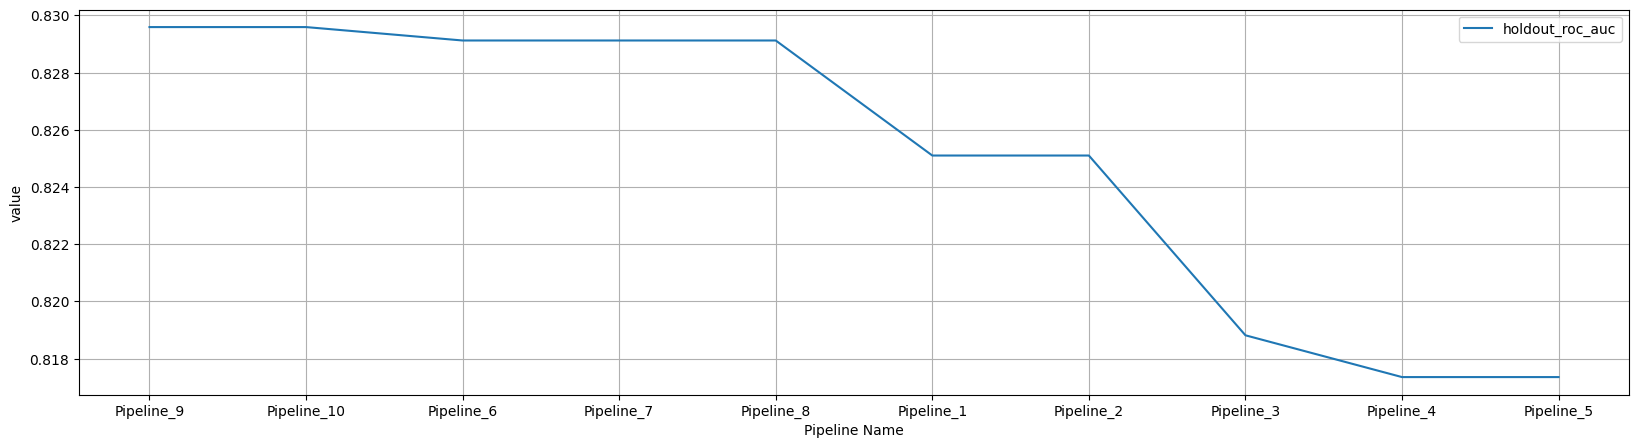

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

pd.options.plotting.backend = "matplotlib"

plt.figure(figsize=(20, 5))
summary.holdout_roc_auc.plot(label="holdout_roc_auc")
plt.ylabel(ylabel="value")
plt.xticks(
    ticks=range(len(summary.holdout_roc_auc)), labels=summary.holdout_roc_auc.index
)
plt.grid()
plt.legend()
plt.show()

<a id="4.-Deploy-and-Score"></a>
## 4. Deploy and Score

In this section you will learn how to deploy and score trained model using project in a specified deployment space as a webservice and batch using WML instance.

### Webservice deployment creation

In [18]:
from ibm_watsonx_ai.deployment import WebService

service = WebService(
    source_instance_credentials=credentials,
    source_project_id=project_id,
    target_instance_credentials=credentials,
    target_space_id=space_id,
)

service.create(
    experiment_run_id=run_details["metadata"]["id"],
    model="Pipeline_1",
    deployment_name="Credit Risk Deployment AutoAI",
)

Preparing an AutoAI Deployment...
Published model uid: 9a26cd8d-061e-47f6-9b2c-bb37af0c7c5e
Deploying model 9a26cd8d-061e-47f6-9b2c-bb37af0c7c5e using V4 client.


######################################################################################

Synchronous deployment creation for id: '9a26cd8d-061e-47f6-9b2c-bb37af0c7c5e' started

######################################################################################


initializing
Note: online_url is deprecated and will be removed in a future release. Use serving_urls instead.
....
ready


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='1aedffbb-4437-451d-9f78-75151ee58879'
-----------------------------------------------------------------------------------------------




Deployment object could be printed to show basic information:

In [ ]:
print(service)

To show all available information about the deployment use the `.get_params()` method:

In [ ]:
service.get_params()

### Scoring of webservice
You can make scoring request by calling `score()` on deployed pipeline.

In [ ]:
train_df = pipeline_optimizer.get_data_connections()[0].read()

train_X = train_df.drop(["Risk"], axis=1)
train_y = train_df.Risk.values

In [22]:
predictions = service.score(payload=train_X.iloc[:10])
predictions

{'predictions': [{'fields': ['prediction', 'probability'],
   'values': [['No Risk', [0.6722619492984393, 0.3277380507015607]],
    ['No Risk', [0.7463715340362654, 0.25362846596373456]],
    ['No Risk', [0.8389065655314143, 0.16109343446858565]],
    ['No Risk', [0.5417064635733093, 0.45829353642669074]],
    ['Risk', [0.10046554443553835, 0.8995344555644617]],
    ['Risk', [0.015637843561548737, 0.9843621564384513]],
    ['No Risk', [0.6199513834792403, 0.3800486165207597]],
    ['No Risk', [0.6893342531092224, 0.3106657468907776]],
    ['No Risk', [0.8737911497882562, 0.1262088502117438]],
    ['Risk', [0.02874258944966579, 0.9712574105503342]]]}]}

If you want to work with the web service in an external Python application you can retrieve the service object by:
 - Initialize the service by `service = WebService(wml_credentials)`
 - Get deployment_id by `service.list()` method
 - Get webservice object by `service.get('deployment_id')` method

After that you can call `service.score()` method.

### Deleting deployment
You can delete the existing deployment by calling the `service.delete()` command.
To list the existing web services you can use `service.list()`.

### Batch deployment creation

A batch deployment processes input data from a inline data and return predictions in scoring details or processes from data asset and writes the output to a file.

In [23]:
batch_payload_df = train_df.drop(["Risk"], axis=1)[:5]
batch_payload_df

,CheckingStatus,LoanDuration,CreditHistory,LoanPurpose,LoanAmount,ExistingSavings,EmploymentDuration,InstallmentPercent,Sex,OthersOnLoan,CurrentResidenceDuration,OwnsProperty,Age,InstallmentPlans,Housing,ExistingCreditsCount,Job,Dependents,Telephone,ForeignWorker
0,0_to_200,31,credits_paid_to_date,other,1889,100_to_500,less_1,3,female,none,3,savings_insurance,32,none,own,1,skilled,1,none,yes
1,less_0,18,credits_paid_to_date,car_new,462,less_100,1_to_4,2,female,none,2,savings_insurance,37,stores,own,2,skilled,1,none,yes
2,less_0,15,prior_payments_delayed,furniture,250,less_100,1_to_4,2,male,none,3,real_estate,28,none,own,2,skilled,1,yes,no
3,0_to_200,28,credits_paid_to_date,retraining,3693,less_100,greater_7,3,male,none,2,savings_insurance,32,none,own,1,skilled,1,none,yes
4,no_checking,28,prior_payments_delayed,education,6235,500_to_1000,greater_7,3,male,none,3,unknown,57,none,own,2,skilled,1,none,yes


Create batch deployment for `Pipeline_2` created in AutoAI experiment with the `run_id`.

In [24]:
from ibm_watsonx_ai.deployment import Batch

service_batch = Batch(
    source_wml_credentials=credentials,
    source_project_id=project_id,
    target_wml_credentials=credentials,
    target_space_id=space_id,
)
service_batch.create(
    experiment_run_id=run_details["metadata"]["id"],
    model="Pipeline_2",
    deployment_name="Credit Risk Batch Deployment AutoAI",
)

Preparing an AutoAI Deployment...
Published model uid: 860dac03-213f-47ac-821e-f133d9346ec3
Deploying model 860dac03-213f-47ac-821e-f133d9346ec3 using V4 client.


######################################################################################

Synchronous deployment creation for id: '860dac03-213f-47ac-821e-f133d9346ec3' started

######################################################################################


ready
Note: The `/text/generation` and `/text/generation_stream` endpoints will be deprecated in an upcoming release and removed in a future release.
.


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='324573a5-9d64-46b0-bfe7-d083624782a7'
-----------------------------------------------------------------------------------------------




### Score batch deployment with inline payload as pandas DataFrame.

In [25]:
scoring_params = service_batch.run_job(payload=batch_payload_df, background_mode=False)

Note: The `/text/generation` and `/text/generation_stream` endpoints will be deprecated in an upcoming release and removed in a future release.


##########################################################################

Synchronous scoring for id: '1daf763b-513d-4254-b154-a95a6691ad68' started

##########################################################################


queued..
completed
Scoring job  '1daf763b-513d-4254-b154-a95a6691ad68' finished successfully.


In [26]:
scoring_params["entity"]["scoring"].get("predictions")

[{'fields': ['prediction', 'probability'],
  'values': [['No Risk', [0.6722619492984393, 0.3277380507015607]],
   ['No Risk', [0.7463715340362654, 0.25362846596373456]],
   ['No Risk', [0.8389065655314143, 0.16109343446858565]],
   ['No Risk', [0.5417064635733093, 0.45829353642669074]],
   ['Risk', [0.10046554443553835, 0.8995344555644617]]]}]

### Deleting batch deployment
You can delete the existing deployment by calling the `service_batch.delete()` command.
To list the existing: 
- batch services you can use `service_batch.list()`, 
- scoring jobs you can use `service_batch.list_jobs()`.

<a id="5.-Cleanup"></a>
## 5. Cleanup

If you want to clean up all created assets:
- experiments
- trainings
- pipelines
- model definitions
- models
- functions
- deployments

please follow up this sample [notebook](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/notebooks/python_sdk/instance-management/Machine%20Learning%20artifacts%20management.ipynb).

<a id="6.-Summary-and-next-steps"></a>
## 6. Summary and next steps

You successfully completed this notebook!
 
You learned how to use `watsonx.ai` to run AutoAI experiments using Watson Studio project. 
 
Check out our _<a href="https://ibm.github.io/watsonx-ai-python-sdk/samples.html" target="_blank" rel="noopener no referrer">Online Documentation</a>_ for more samples, tutorials, documentation, how-tos, and blog posts. 

### Authors

**Jan Sołtysik**, Intern in watsonx.ai

**Mateusz Szewczyk**, Software Engineer at watsonx.ai.

Copyright © 2020-2026 IBM. This notebook and its source code are released under the terms of the MIT License.